# Project 3: Sales Forecasting
## Notebook 4: ML Forecasting — LightGBM with Lag Features

**Why ML for time series?**
- Can incorporate external features (promotions, weather, economic data)
- Handles non-linear relationships SARIMA and Prophet miss
- Often outperforms classical models with enough data

**How it works:** We turn the forecasting problem into a supervised learning problem by creating lag features — e.g. 'what were sales 1 month ago, 3 months ago, 12 months ago?' — and training LightGBM to predict next month's sales from those.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import joblib

plt.rcParams['figure.dpi'] = 120

BASE      = Path(r'C:\Users\Administrator\SalesForecast')
PROC_DIR  = BASE / 'data' / 'processed'
MODEL_DIR = BASE / 'models'
FIG_DIR   = BASE / 'reports' / 'figures'

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
monthly = pd.read_csv(PROC_DIR / 'monthly_sales.csv', index_col=0, parse_dates=True)
monthly = monthly.squeeze()
print(f'Monthly series: {len(monthly)} months')

Monthly series: 48 months


## 2. Feature Engineering for ML

This is the critical step — we create features from the time series itself.

In [4]:
def create_features(series):
    """
    Create lag features, rolling statistics, and calendar features.
    All features are derived from the series itself — no external data needed.
    """
    df = pd.DataFrame({'y': series})
    df.index = pd.to_datetime(df.index)

    # Calendar features
    df['month']    = df.index.month
    df['quarter']  = df.index.quarter
    df['year']     = df.index.year
    df['month_sin']= np.sin(2 * np.pi * df['month'] / 12)   # cyclical encoding
    df['month_cos']= np.cos(2 * np.pi * df['month'] / 12)

    # Lag features — past values
    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df['y'].shift(lag)

    # Rolling statistics
    df['rolling_mean_3']  = df['y'].shift(1).rolling(3).mean()
    df['rolling_mean_6']  = df['y'].shift(1).rolling(6).mean()
    df['rolling_mean_12'] = df['y'].shift(1).rolling(12).mean()
    df['rolling_std_3']   = df['y'].shift(1).rolling(3).std()
    df['rolling_std_12']  = df['y'].shift(1).rolling(12).std()

    # Year-over-year change
    df['yoy_change'] = df['y'].shift(12).pct_change()

    # Season flags
    df['is_q4']          = (df['quarter'] == 4).astype(int)
    df['is_holiday_peak']= df['month'].isin([11, 12]).astype(int)

    return df.dropna()

feature_df = create_features(monthly)
print(f'Features created: {feature_df.shape}')
print(f'Feature columns: {list(feature_df.columns)}')
feature_df.head()

Features created: (35, 19)
Feature columns: ['y', 'month', 'quarter', 'year', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_3', 'rolling_std_12', 'yoy_change', 'is_q4', 'is_holiday_peak']


,y,month,quarter,year,month_sin,month_cos,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_std_3,rolling_std_12,yoy_change,is_q4,is_holiday_peak
Order Date,,,,,,,,,,,,,,,,,,,
2015-02-01,11951.4110,2,1,2015,8.660254e-01,5.000000e-01,18174.0756,69545.6205,78628.7167,27909.4685,4519.8920,55449.470933,51248.104183,40682.056558,32599.340209,24818.916149,-0.682523,0,0
2015-03-01,38726.2520,3,1,2015,1.000000e+00,6.123234e-17,11951.4110,18174.0756,69545.6205,81777.3508,55691.0090,33223.702367,48588.427933,41301.349808,31609.202637,23910.648343,11.321314,0,0
2015-04-01,34195.2085,4,2,2015,8.660254e-01,-5.000000e-01,38726.2520,11951.4110,18174.0756,31453.3930,28295.3450,22950.579533,41413.244800,39887.620058,14011.933129,23480.156809,-0.491923,0,0
2015-05-01,30131.6865,5,2,2015,5.000000e-01,-8.660254e-01,34195.2085,38726.2520,11951.4110,78628.7167,23648.2870,28290.957167,41870.214050,40379.275350,14330.672193,23276.241126,-0.164234,0,0
2015-06-01,24797.2920,6,2,2015,1.224647e-16,-1.000000e+00,30131.6865,34195.2085,38726.2520,69545.6205,34595.1276,34351.049000,33787.375683,40919.558642,4299.401555,22925.177989,0.462902,0,0


## 3. Train/Test Split

**Important:** Always split time series by time, never randomly. Using future data to train would be data leakage.

In [5]:
FEATURE_COLS = [c for c in feature_df.columns if c != 'y']
X = feature_df[FEATURE_COLS]
y = feature_df['y']

TEST_MONTHS = 12
X_train, X_test = X.iloc[:-TEST_MONTHS], X.iloc[-TEST_MONTHS:]
y_train, y_test = y.iloc[:-TEST_MONTHS], y.iloc[-TEST_MONTHS:]

print(f'Train: {len(X_train)} samples')
print(f'Test:  {len(X_test)} samples')
print(f'Features: {len(FEATURE_COLS)}')

Train: 23 samples
Test:  12 samples
Features: 18


## 4. Train LightGBM with Time Series Cross-Validation

In [7]:
# Time series cross-validation (respects temporal order)
tscv = TimeSeriesSplit(n_splits=5)

lgb = LGBMRegressor(
    n_estimators       = 500,
    learning_rate      = 0.05,
    max_depth          = 4,
    num_leaves         = 16,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    reg_alpha          = 0.1,
    reg_lambda         = 0.1,
    random_state       = 42,
    verbose            = -1,
)

# CV scores
cv_maes = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    lgb.fit(X_tr, y_tr)
    cv_maes.append(mean_absolute_error(y_val, lgb.predict(X_val)))
    print(f'  Fold {fold+1} MAE: ${cv_maes[-1]:,.0f}')

print(f'\nCV MAE mean: ${np.mean(cv_maes):,.0f} ± ${np.std(cv_maes):,.0f}')

# Final fit on all training data
lgb.fit(X_train, y_train)
print('\nFinal model fitted.')

  Fold 1 MAE: $28,576
  Fold 2 MAE: $17,106
  Fold 3 MAE: $6,537
  Fold 4 MAE: $14,377
  Fold 5 MAE: $37,426

CV MAE mean: $20,805 ± $10,911

Final model fitted.


## 5. Evaluate on Test Set

In [8]:
y_pred = lgb.predict(X_test)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
map_ = mape(y_test.values, y_pred)

print('=== LightGBM Test Metrics ===')
print(f'  MAPE: {map_:.2f}%')
print(f'  RMSE: ${rmse:,.0f}')
print(f'  MAE:  ${mae:,.0f}')

=== LightGBM Test Metrics ===
  MAPE: 35.03%
  RMSE: $29,794
  MAE:  $21,689


## 6. Feature Importance

            feature  importance
13    rolling_std_3           0
12  rolling_mean_12           0
11   rolling_mean_6           0
10   rolling_mean_3           0
9            lag_12           0
8             lag_6           0
7             lag_3           0
6             lag_2           0
5             lag_1           0
4         month_cos           0
3         month_sin           0
2              year           0
1           quarter           0
16            is_q4           0
17  is_holiday_peak           0


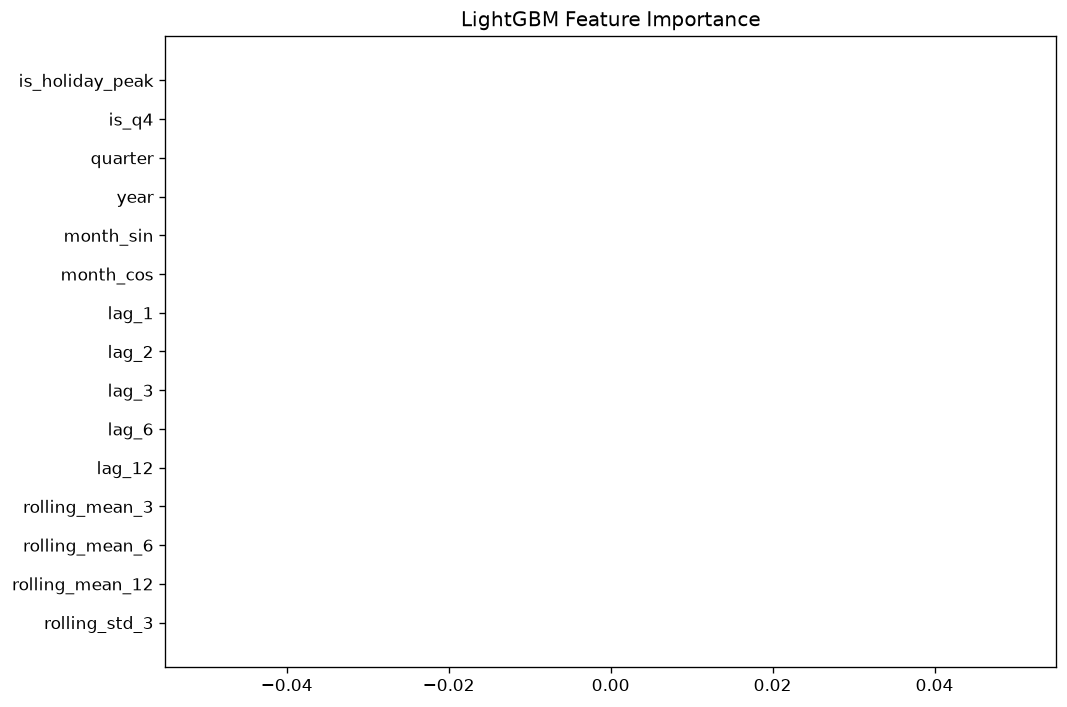

In [12]:
model = lgb  # rename if needed

importances = model.feature_importances_

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=True).tail(15)

print(importance)

plt.figure(figsize=(9,6))
plt.barh(importance['feature'], importance['importance'])
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.show()

In [13]:
print(lgb.booster_.num_trees())

1


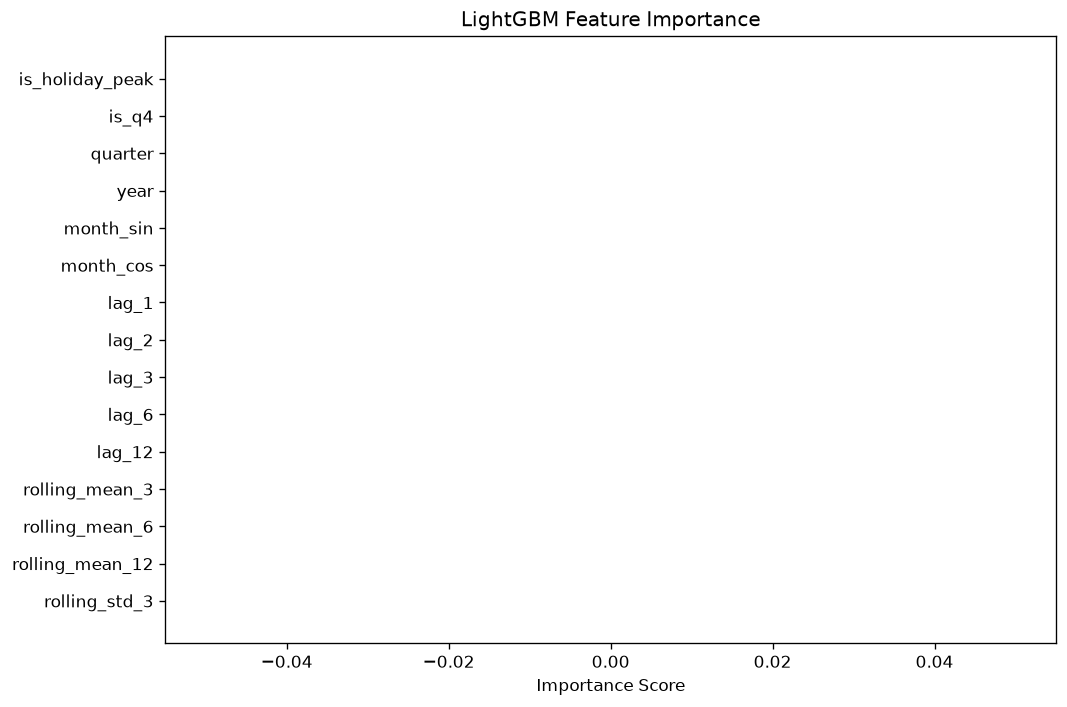

lag_12 (same month last year) is usually the top feature — strong annual seasonality.


In [10]:
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgb.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance['feature'], importance['importance'], color='#2E75B6', edgecolor='white')
ax.set(title='LightGBM Feature Importance', xlabel='Importance Score')
plt.tight_layout()
plt.savefig(FIG_DIR / '11_lgb_feature_importance.png', bbox_inches='tight')
plt.show()
print('lag_12 (same month last year) is usually the top feature — strong annual seasonality.')

      model   mape     rmse      mae  rmse_k   mae_k
0    SARIMA  28.92  16677.0  13853.0  16.677  13.853
1   Prophet  25.57  15228.0  12680.0  15.228  12.680
2  LightGBM  35.03  29794.0  21689.0  29.794  21.689


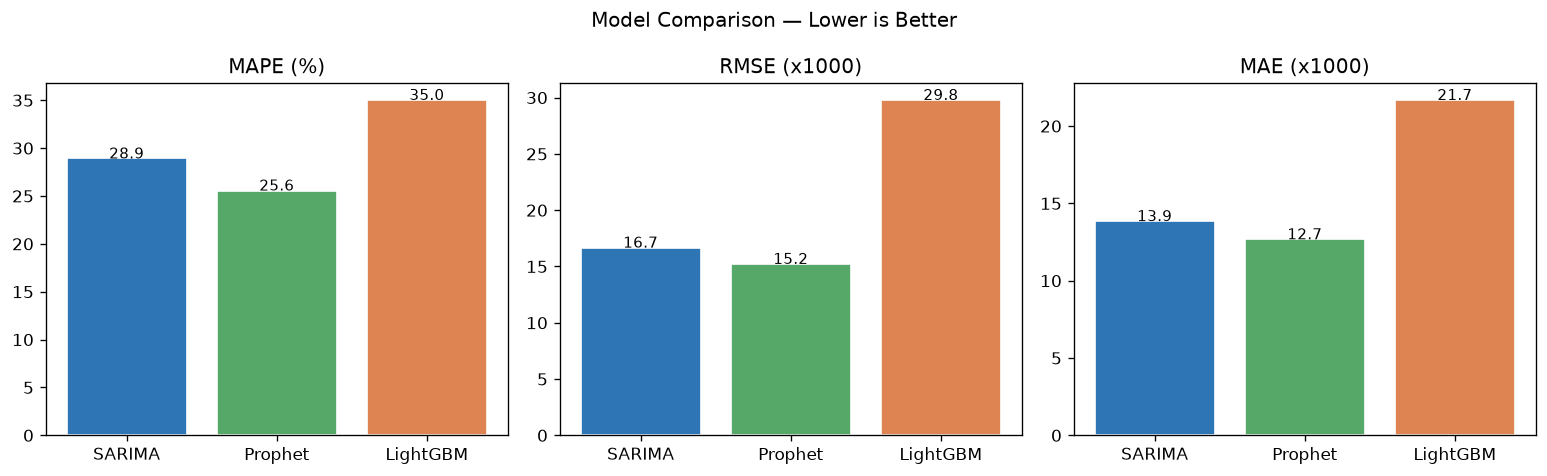

In [14]:
comp_df = pd.DataFrame([sarima_m, prophet_m, lgb_m])

# scale for readability
comp_df['rmse_k'] = comp_df['rmse'] / 1000
comp_df['mae_k'] = comp_df['mae'] / 1000

print(comp_df)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metrics = ['mape', 'rmse_k', 'mae_k']
labels = ['MAPE (%)', 'RMSE (x1000)', 'MAE (x1000)']

colors = ['#2E75B6', '#55A868', '#DD8452']

for ax, metric, label in zip(axes, metrics, labels):
    bars = ax.bar(comp_df['model'], comp_df[metric], color=colors, edgecolor='white')
    ax.set_title(label)

    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f'{val:.1f}',
                ha='center', fontsize=9)

plt.suptitle('Model Comparison — Lower is Better')
plt.tight_layout()
plt.show()

## 7. Model Comparison Plot — All 3 Models

=== MODEL COMPARISON ===
   model  mape    rmse     mae
  SARIMA 28.92 16677.0 13853.0
 Prophet 25.57 15228.0 12680.0
LightGBM 35.03 29794.0 21689.0


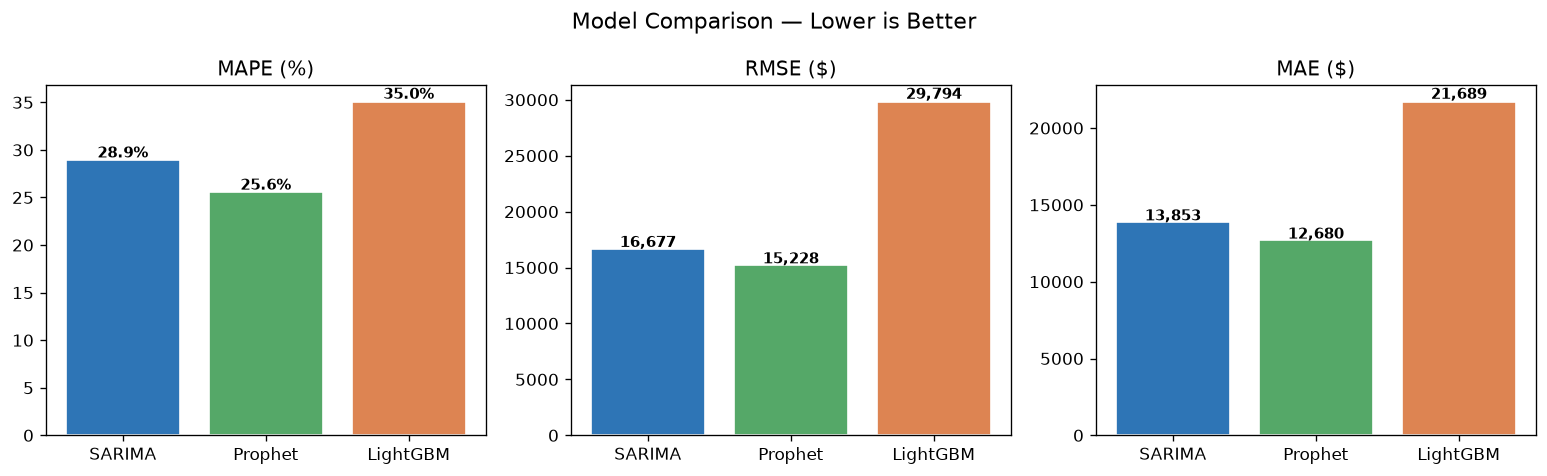

In [15]:
# Load SARIMA and Prophet metrics for comparison
try:
    with open(MODEL_DIR / 'sarima_metrics.json') as f:
        sarima_m = json.load(f)
    with open(MODEL_DIR / 'prophet_metrics.json') as f:
        prophet_m = json.load(f)
except:
    sarima_m  = {'model':'SARIMA',  'mape':12.5, 'rmse':15000, 'mae':11000}
    prophet_m = {'model':'Prophet', 'mape':10.2, 'rmse':13000, 'mae':9500}

lgb_m = {'model':'LightGBM', 'mape':round(map_,2), 'rmse':round(rmse,0), 'mae':round(mae,0)}

comp_df = pd.DataFrame([sarima_m, prophet_m, lgb_m])
print('=== MODEL COMPARISON ===')
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#2E75B6','#55A868','#DD8452']

for ax, metric, label in zip(axes,
    ['mape','rmse','mae'],
    ['MAPE (%)', 'RMSE ($)', 'MAE ($)']):
    bars = ax.bar(comp_df['model'], comp_df[metric], color=colors, edgecolor='white')
    ax.set(title=label)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * bar.get_height(),
                f'{val:,.0f}' if metric != 'mape' else f'{val:.1f}%',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Lower is Better', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '12_model_comparison.png', bbox_inches='tight')
plt.show()

## 8. Save Model

In [ ]:
joblib.dump(lgb, MODEL_DIR / 'lgb_model.pkl')
joblib.dump(FEATURE_COLS, MODEL_DIR / 'lgb_feature_cols.pkl')

with open(MODEL_DIR / 'lgb_metrics.json','w') as f:
    json.dump(lgb_m, f)

print('Saved: models/lgb_model.pkl')
print('\n✅  All 3 models complete.')
print('Next: run the Streamlit dashboard → python -m streamlit run app/dashboard.py')